<a href="https://colab.research.google.com/github/gabrielbarata/MVP-machine-learning/blob/main/MVP_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
try:
  from pathos.multiprocessing import ProcessingPool as Pool
except ModuleNotFoundError as e:
  !pip install pathos
  from pathos.multiprocessing import ProcessingPool as Pool

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.16
    Uninstalling multiprocess-0.70.16:
      Successfully uninstalled multiprocess-0.70.16
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires dill<0.3.9,>=0.3.0, but you have dill 0.4.1 which is incompatible.
datasets 4.0.0 requires multiprocess<0.70.17, but you have multiprocess 0.70.19 which is inc

In [ ]:
import cv2
import numpy as np
import os
from sklearn.model_selection import train_test_split

In [ ]:
import gc
import ctypes

def clear_memory():
    gc.collect()
    ctypes.CDLL('libc.so.6').malloc_trim(0)

tot_cpu = os.cpu_count()
print(f"Número de núcleos: {tot_cpu}")

Número de núcleos: 2


In [ ]:
# SHAPE_X = 32
SHAPE_X = 64

In [ ]:
# import tensorflow as tf
# from keras import layers, models
# import numpy as np
# from pathlib import Path

# # 1. Carregar e preparar o dataset MNIST
# mnist = tf.keras.datasets.mnist
# (x_train, y_train), (x_test, y_test) = mnist.load_data()

# x_raw = np.concat([x_train,x_test])
# y_raw = np.concat([y_train,y_test])


# class_names = {int(i):str(i) for i in np.unique(y_raw)}

# dataset_dir = Path("dataset_mnist").resolve()


# print(f"x_train: {len(x_raw)} x {x_raw[0].shape}, y_train: {y_raw.shape}")
# print(f"Class Names: {class_names}")

In [ ]:
import kagglehub
import os
from pathlib import Path

path = kagglehub.dataset_download("fernando2rad/brain-tumor-mri-images-30-classes" )
print("Dataset baixado em:", path)

dataset_dir = Path("dataset_brain_tumor").resolve()


Using Colab cache for faster access to the 'brain-tumor-mri-images-30-classes' dataset.
Dataset baixado em: /kaggle/input/brain-tumor-mri-images-30-classes


In [ ]:
# import kagglehub
# import os
# from pathlib import Path

# path = kagglehub.dataset_download("vijaykumar1799/face-mask-detection")
# path = f"{path}/Dataset"
# print("Path to dataset files:", path)

# dataset_dir = Path("dataset_face_mask").resolve()


In [ ]:

from PIL import Image

# Função de tarefa sem dependências externas
def process_load_task(args):
    img_path, label = args
    try:
        # Leitura inline (não depende de read_image_helper)
        img = np.array(Image.open(img_path).convert('L'))  #
        # gc.collect()
        # img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            return img, label
    except:
        pass
    # gc.collect()
    return None

def load_kaggle(base_path):
    categories = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
    label_map = {category: i for i, category in enumerate(categories)}

    # Create a reverse map for class names
    class_names = {i: category for category, i in label_map.items()}

    print(f"Encontradas {len(categories)} classes. Preparando lista de tarefas...")

    tasks = []
    for category in categories:
        folder_path = os.path.join(base_path, category)
        label = label_map[category]
        for img_name in os.listdir(folder_path):
            tasks.append((os.path.join(folder_path, img_name), label))

    print(f"Carregando {len(tasks)} imagens em paralelo...")
    with Pool(nodes = tot_cpu) as pool:
        results = pool.map(process_load_task, tasks)
    # results = list(map(process_load_task, tasks))

    valid_results = [r for r in results if r is not None]
    x = [r[0] for r in valid_results]
    y = np.array([r[1] for r in valid_results])

    print(f"x_train: {len(x)} x {x[0].shape}, y_train: {y.shape}")
    print(f"Class Names: {class_names}")

    return x, y, class_names

x_raw, y_all, class_names = load_kaggle(path)



Encontradas 30 classes. Preparando lista de tarefas...
Carregando 11300 imagens em paralelo...
x_train: 11300 x (512, 512), y_train: (11300,)
Class Names: {0: 'Astrocytoma T1', 1: 'Astrocytoma T1C+', 2: 'Astrocytoma T2', 3: 'Ependymoma T1', 4: 'Ependymoma T1C+', 5: 'Ependymoma T2', 6: 'Glioma T1', 7: 'Glioma T1C+', 8: 'Glioma T2', 9: 'Hemangiopericytoma T1', 10: 'Hemangiopericytoma T1C+', 11: 'Hemangiopericytoma T2', 12: 'Meningioma T1', 13: 'Meningioma T1C+', 14: 'Meningioma T2', 15: 'Neurocytoma T1', 16: 'Neurocytoma T1C+', 17: 'Neurocytoma T2', 18: 'Normal T1', 19: 'Normal T1C+', 20: 'Normal T2', 21: 'Oligodendroglioma T1', 22: 'Oligodendroglioma T1C+', 23: 'Oligodendroglioma T2', 24: 'Other T1', 25: 'Other T1C+', 26: 'Other T2', 27: 'Schwannoma T1', 28: 'Schwannoma T1C+', 29: 'Schwannoma T2'}


In [ ]:
def resize_dataset_parallel(x_list, img_size):
    print(f"Redimensionando {len(x_list)} imagens para {img_size}...")


    def local_resize(img):
        return cv2.resize(img, img_size)

    with Pool(nodes = tot_cpu) as pool:
        results = pool.map(local_resize, x_list)

    # results = list(map(local_resize, x_list))

    results = np.array(results)

    print(f"resize_dataset_parallel: {results.shape}")

    return results

d0_max = max([i.shape[0] for i in x_raw])
d1_max = max([i.shape[1] for i in x_raw])

x_raw = resize_dataset_parallel(x_raw, img_size=(d0_max, d1_max))
clear_memory()

x_all = resize_dataset_parallel(x_raw, img_size=(SHAPE_X, SHAPE_X))

clear_memory()

Redimensionando 11300 imagens para (512, 512)...
resize_dataset_parallel: (11300, 512, 512)
Redimensionando 11300 imagens para (64, 64)...
resize_dataset_parallel: (11300, 64, 64)




original




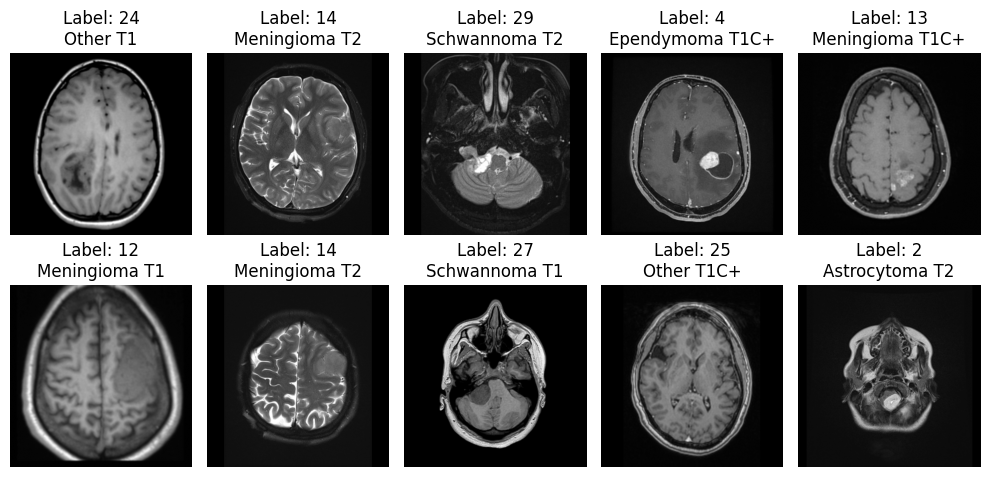



resized




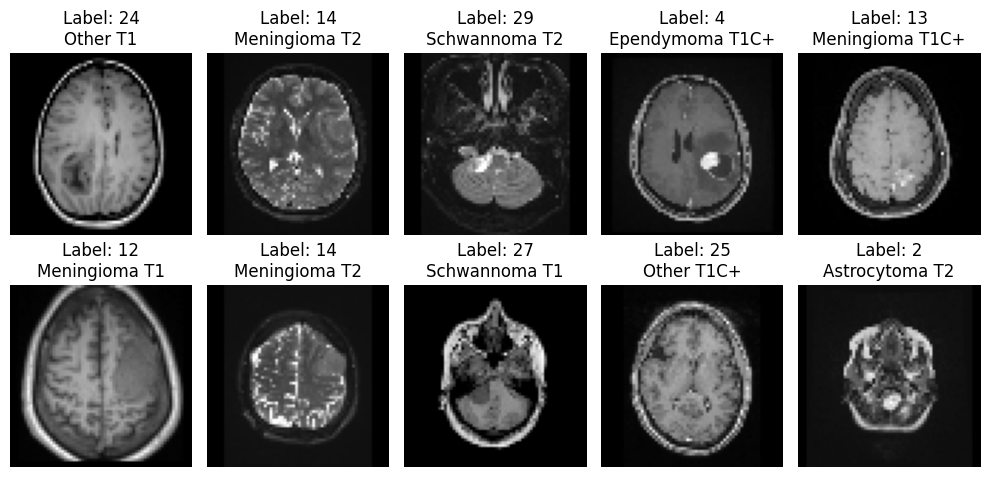

In [ ]:
import matplotlib.pyplot as plt

def display_dataset(x, y, idxs=None):
  plt.figure(figsize=(10, 5))
  if idxs is None:
      idxs = np.random.choice(len(x), 10, replace=False)
  for n, i in enumerate(idxs):
      plt.subplot(2, 5, n + 1)
      plt.imshow(x[i], cmap='gray')
      plt.title(f"Label: {y[i]}\n{class_names[y[i]]}")
      plt.axis('off')

  plt.tight_layout()
  plt.show()


idxs = np.random.choice(len(x_raw), 10, replace=False)
print("\n\noriginal\n\n")
display_dataset(x_raw, y_all,idxs)
print("\n\nresized\n\n")
display_dataset(x_all, y_all,idxs)


In [ ]:

def remove_duplicates_and_sync(x_data, y_data):
    x_flat = x_data.reshape(x_data.shape[0], -1)
    _, unique_indices = np.unique(x_flat, axis=0, return_index=True)

    x_unique = x_data[unique_indices]
    y_unique = y_data[unique_indices]

    print(f"Original: {len(x_data)} amostras. Após remover {len(x_data) - len(x_unique)} duplicatas: {len(x_unique)} amostras.")

    print(f"remove_duplicates_and_sync: {x_unique.shape} {y_unique.shape}")

    return x_unique, y_unique

# Exemplo de uso com x_norm e y_norm
x_unique, y_unique = remove_duplicates_and_sync(x_all, y_all)



Original: 11300 amostras. Após remover 1865 duplicatas: 9435 amostras.
remove_duplicates_and_sync: (9435, 64, 64) (9435,)


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x_unique, y_unique, test_size=0.3, random_state=42, shuffle=True
)

print(f"\nFormato final:")
print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test: {x_test.shape}, y_test: {y_test.shape}")


Formato final:
x_train: (6604, 64, 64), y_train: (6604,)
x_test: (2831, 64, 64), y_test: (2831,)


In [ ]:
def print_value_and_shape(val):
  print()
  print(val)
  print()
  print("shape:",val.shape)
  print()

In [ ]:
from imblearn.over_sampling import RandomOverSampler
import numpy as np
import pandas as pd

def get_balanced_dataset(x, y):

  n_samples, *n_features = x.shape

  x_flat = x.reshape((n_samples, np.prod(n_features)))

  ros = RandomOverSampler(random_state=42)
  x_balanced, y_balanced = ros.fit_resample(x_flat, y)

  x_balanced = x_balanced.reshape((-1, *n_features))

  print("\n\noriginal\n\n")
  print_value_and_shape(pd.Series(y).value_counts())

  print("\n\nbalanceado\n\n")
  print_value_and_shape(pd.Series(y_balanced).value_counts().sort_index())

  return x_balanced, y_balanced



x_train, y_train = get_balanced_dataset(x_train, y_train)
x_test, y_test = get_balanced_dataset(x_test, y_test)
clear_memory()



original



13    644
25    466
12    404
28    313
0     279
1     277
18    276
7     271
14    266
24    258
20    242
6     219
27    209
4     208
26    199
29    192
3     187
19    186
2     185
8     172
5     165
16    164
10    149
21    136
22    123
15    108
17     87
23     85
9      77
11     57
Name: count, dtype: int64

shape: (30,)



balanceado



0     644
1     644
2     644
3     644
4     644
5     644
6     644
7     644
8     644
9     644
10    644
11    644
12    644
13    644
14    644
15    644
16    644
17    644
18    644
19    644
20    644
21    644
22    644
23    644
24    644
25    644
26    644
27    644
28    644
29    644
Name: count, dtype: int64

shape: (30,)



original



13    260
25    200
12    181
28    138
1     129
18    129
7     120
6     114
20    114
4     111
14    110
26    104
0     101
24     98
27     86
2      80
3      77
29     73
19     73
5      73
8      65
21     58
22     57
16     57
17     53
15     52
10     40
9   

In [ ]:
import numpy as np

def check_data_overlap(x_train_data, x_test_data):

    print("Verificando sobreposição de dados...")

    train_hashes = set()
    for img in x_train_data:
        train_hashes.add(img.tobytes())

    test_hashes = set()
    for img in x_test_data:
        test_hashes.add(img.tobytes())

    overlap = train_hashes.intersection(test_hashes)

    if len(overlap) > 0:
        print(f"ATENÇÃO: Foram encontrados {len(overlap)} elementos idênticos entre os conjuntos de treinamento e teste.")
    else:
        print("Nenhuma sobreposição encontrada entre os conjuntos de treinamento e teste.")

# Chamando a função com os dados existentes no kernel
check_data_overlap(x_train, x_test)


Verificando sobreposição de dados...
Nenhuma sobreposição encontrada entre os conjuntos de treinamento e teste.


In [ ]:

all_xy_arrays = {
    "x_all": x_all,

    "x_train": x_train,
    "x_test": x_test,

    "y_train": y_train,
    "y_test": y_test,
}

all_xy_arrays = {f"{k}_{SHAPE_X}x{SHAPE_X}":v for k,v in all_xy_arrays.items()}

all_xy_arrays = {
    "class_names":np.array(class_names),
    "x_raw": x_raw,
    "y_all": y_all,
    **all_xy_arrays
}

for key, value in all_xy_arrays.items():
    if isinstance(value, list):
        print(f"Key: {key}, Type: {type(value)}, Length: {len(value)}")
        if len(value) > 0 and hasattr(value[0], 'shape'):
            print(f"  Example element shape: {value[0].shape}")
    else:
        print(f"Key: {key}, Shape: {value.shape}")

clear_memory()

Key: class_names, Shape: ()
Key: x_raw, Shape: (11300, 512, 512)
Key: y_all, Shape: (11300,)
Key: x_all_64x64, Shape: (11300, 64, 64)
Key: x_train_64x64, Shape: (19320, 64, 64)
Key: x_test_64x64, Shape: (7800, 64, 64)
Key: y_train_64x64, Shape: (19320,)
Key: y_test_64x64, Shape: (7800,)


In [ ]:
import os
import numpy as np


dataset_dir.mkdir(exist_ok=True)


for key, value in all_xy_arrays.items():
    filename = dataset_dir/f"{key}.npy"
    clear_memory()
    np.save(filename, value)
    clear_memory()
    print(f"Salvo '{key}' em '{filename}' com shape {value.shape}")

Salvo 'class_names' em '/content/dataset_brain_tumor/class_names.npy' com shape ()
Salvo 'x_raw' em '/content/dataset_brain_tumor/x_raw.npy' com shape (11300, 512, 512)
Salvo 'y_all' em '/content/dataset_brain_tumor/y_all.npy' com shape (11300,)
Salvo 'x_all_64x64' em '/content/dataset_brain_tumor/x_all_64x64.npy' com shape (11300, 64, 64)
Salvo 'x_train_64x64' em '/content/dataset_brain_tumor/x_train_64x64.npy' com shape (19320, 64, 64)
Salvo 'x_test_64x64' em '/content/dataset_brain_tumor/x_test_64x64.npy' com shape (7800, 64, 64)
Salvo 'y_train_64x64' em '/content/dataset_brain_tumor/y_train_64x64.npy' com shape (19320,)
Salvo 'y_test_64x64' em '/content/dataset_brain_tumor/y_test_64x64.npy' com shape (7800,)


In [ ]:
import os
import numpy as np
from pathlib import Path

# Ensure dataset_dir is defined, if not already in the kernel
# In this case, it is already defined as Path('dataset_brain_tumor').resolve()

all_xy_arrays = {}

print(f"Recriando all_xy_arrays a partir de: {dataset_dir}")
for file_path in dataset_dir.glob("*"):

  key_name = file_path.stem
  try:
      clear_memory()
      loaded_data = np.load(file_path, allow_pickle=True)
      clear_memory()
      all_xy_arrays[key_name] = loaded_data
      print(f"Carregado '{key_name}' com shape {loaded_data.shape}")
  except Exception as e:
      print(f"Erro ao carregar '{file_path}': {e}")

print("\nConteúdo do all_xy_arrays:")
for key, value in all_xy_arrays.items():
    print(f"  '{key}': {type(value)} com shape {value.shape}")

Recriando all_xy_arrays a partir de: /content/dataset_brain_tumor
Carregado 'class_names' com shape ()
Carregado 'x_all_64x64' com shape (11300, 64, 64)
Carregado 'x_test_64x64' com shape (7800, 64, 64)
Carregado 'y_test_64x64' com shape (7800,)
Carregado 'x_train_64x64' com shape (19320, 64, 64)
Carregado 'y_train_64x64' com shape (19320,)
Carregado 'y_all' com shape (11300,)
Carregado 'x_raw' com shape (11300, 512, 512)

Conteúdo do all_xy_arrays:
  'class_names': <class 'numpy.ndarray'> com shape ()
  'x_all_64x64': <class 'numpy.ndarray'> com shape (11300, 64, 64)
  'x_test_64x64': <class 'numpy.ndarray'> com shape (7800, 64, 64)
  'y_test_64x64': <class 'numpy.ndarray'> com shape (7800,)
  'x_train_64x64': <class 'numpy.ndarray'> com shape (19320, 64, 64)
  'y_train_64x64': <class 'numpy.ndarray'> com shape (19320,)
  'y_all': <class 'numpy.ndarray'> com shape (11300,)
  'x_raw': <class 'numpy.ndarray'> com shape (11300, 512, 512)


In [ ]:
shape_str = f"_{SHAPE_X}x{SHAPE_X}"

x_raw = all_xy_arrays['x_raw']
x_all = all_xy_arrays[f'x_all{shape_str}']
y_all = all_xy_arrays['y_all']
x_train = all_xy_arrays[f'x_train{shape_str}']
x_test = all_xy_arrays[f'x_test{shape_str}']
y_train = all_xy_arrays[f'y_train{shape_str}']
y_test = all_xy_arrays[f'y_test{shape_str}']
class_names = all_xy_arrays["class_names"].item()

print("Variáveis recriadas individualmente:")
print(f"  x_raw shape: {x_raw.shape}")
print(f"  x_all shape: {x_all.shape}")
print(f"  y_all shape: {y_all.shape}")
print(f"  x_train shape: {x_train.shape}")
print(f"  x_test shape: {x_test.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  y_test shape: {y_test.shape}")
print(f"  class_names: {class_names}")
clear_memory()

Variáveis recriadas individualmente:
  x_raw shape: (11300, 512, 512)
  x_all shape: (11300, 64, 64)
  y_all shape: (11300,)
  x_train shape: (19320, 64, 64)
  x_test shape: (7800, 64, 64)
  y_train shape: (19320,)
  y_test shape: (7800,)
  class_names: {0: 'Astrocytoma T1', 1: 'Astrocytoma T1C+', 2: 'Astrocytoma T2', 3: 'Ependymoma T1', 4: 'Ependymoma T1C+', 5: 'Ependymoma T2', 6: 'Glioma T1', 7: 'Glioma T1C+', 8: 'Glioma T2', 9: 'Hemangiopericytoma T1', 10: 'Hemangiopericytoma T1C+', 11: 'Hemangiopericytoma T2', 12: 'Meningioma T1', 13: 'Meningioma T1C+', 14: 'Meningioma T2', 15: 'Neurocytoma T1', 16: 'Neurocytoma T1C+', 17: 'Neurocytoma T2', 18: 'Normal T1', 19: 'Normal T1C+', 20: 'Normal T2', 21: 'Oligodendroglioma T1', 22: 'Oligodendroglioma T1C+', 23: 'Oligodendroglioma T2', 24: 'Other T1', 25: 'Other T1C+', 26: 'Other T2', 27: 'Schwannoma T1', 28: 'Schwannoma T1C+', 29: 'Schwannoma T2'}


In [ ]:
def normalize_data(x):
    x = x.astype('float32')
    _, *axis_ = range(len(x.shape))
    axis_ = tuple(axis_)

    mean = np.mean(x, axis=axis_, keepdims=True)
    std = np.std(x, axis=axis_, keepdims=True)

    std = np.where(std == 0, 1e-7, std)

    x_norm = (x - mean) / std

    return x_norm


x_all_norm = normalize_data(x_all)

_, *axis_ = range(len(x_all_norm.shape))
axis_ = tuple(axis_)

print("\n\noriginal\n\n")
print("mean")
print_value_and_shape(np.mean(x_all, axis=axis_))
print("std")
print_value_and_shape(np.std(x_all, axis=axis_))

print("\n\nnormalizado\n\n")
print("mean")
print_value_and_shape(np.mean(x_all_norm, axis=axis_))
print("std")
print_value_and_shape(np.std(x_all_norm, axis=axis_))



original


mean

[28.32763672 50.84448242 19.22265625 ... 40.17773438 19.60375977
 30.66870117]

shape: (11300,)

std

[52.05970579 53.83167381 31.17075475 ... 49.82357696 27.59380265
 41.91780528]

shape: (11300,)



normalizado


mean

[ 0.0000000e+00  2.6077032e-08  3.7252903e-08 ...  7.4505806e-09
  3.7252903e-09 -1.3969839e-09]

shape: (11300,)

std

[1.         1.         1.         ... 1.         0.99999994 1.        ]

shape: (11300,)



In [ ]:
x_train_norm = normalize_data(x_train)
x_test_norm = normalize_data(x_test)

x_train_cnn = x_train_norm[..., None]
x_test_cnn = x_test_norm[..., None]

x_train_transfer = np.repeat(x_train[..., np.newaxis], 3, -1)
x_test_transfer = np.repeat(x_test[..., np.newaxis], 3, -1)


In [ ]:
_, *x_dims = x_train.shape
num_classes = int(y_train.max()) + 1
x_dims, num_classes

([64, 64], 30)

In [ ]:
import tensorflow as tf

# Verificar se a GPU está disponível
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Configurar para que o TensorFlow aloque memória conforme necessário,
        # em vez de reservar toda a memória da GPU de uma vez.
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs")
        print("TensorFlow configurado para usar GPU.")
    except RuntimeError as e:
        # Visibilidade de dispositivos deve ser configurada antes de inicializar as GPUs
        print(e)
else:
    print("Nenhuma GPU detectada. Vá em 'Ambiente de execução' -> 'Alterar tipo de ambiente de execução' e selecione uma GPU (T4, L4, etc).")

1 Physical GPUs, 1 Logical GPUs
TensorFlow configurado para usar GPU.


In [ ]:
import tensorflow as tf
import keras
from keras import layers, models, Input
from keras.callbacks import ModelCheckpoint

def plot_model(model):
  return keras.utils.plot_model(model, expand_nested=True, show_shapes=True, show_layer_activations=True)

def build_cnn_model(make_model_func, num_colors = 1, optimizer = 'adam'):

    model = make_model_func(Input(shape=(SHAPE_X, SHAPE_X, num_colors)))
    model.summary()
    plot_model(model)
    model = make_model_func(Input(shape=(None, None, num_colors)))
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


def fit(model, x_train_inp, x_test_inp):
  history = model.fit(
    x_train_inp, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(x_test_inp, y_test),
    callbacks=[model_checkpoint_callback]
  )
  return history


def get_best_model(x_test_inp):
  model = models.load_model(checkpoint_filepath)
  eval(model, x_test_inp)
  return model

def eval(model, x_test_inp):
  loss, acc = model.evaluate(x_test_inp, y_test)
  print(f"\nAcurácia da CNN no conjunto de teste: {acc:.4f}")

checkpoint_filepath = 'best_model_cnn.keras'
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
)

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
  plt.figure(figsize=(12, 4))

  plt.subplot(1, 2, 1)
  plt.plot(history.history['accuracy'], label='Training Accuracy')
  plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
  plt.title('Training and Validation Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.grid(True)

  plt.subplot(1, 2, 2)
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.title('Training and Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)

  plt.tight_layout()
  plt.show()

In [ ]:
raise Exception("parada forçada")

Exception: parada forçada

In [ ]:
#CNN PADRÃO
def make_model(inputs):
  x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D((2, 2))(x)

  x = layers.Conv2D(64, (3, 3), activation='relu')(x)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D((2, 2))(x)

  x = layers.Conv2D(128, (3, 3), activation='relu')(x)
  x = layers.BatchNormalization()(x)
  x = layers.GlobalAveragePooling2D()(x)

  x = layers.Dense(256, activation='relu')(x)
  x = layers.Dropout(0.5)(x)
  outputs = layers.Dense(num_classes, activation='softmax')(x)

  model = models.Model(inputs=inputs, outputs=outputs)
  return model

current_x_test = x_test_cnn

model_temp = build_cnn_model(make_model)

history = fit(model_temp, x_train_cnn, x_test_cnn)

#max acc val: 0.8794


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │         7,710 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,302 (524.62 KB)

 Trainable params: 133,854 (522.87 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.3488 - loss: 2.1789 - val_accuracy: 0.4179 - val_loss: 1.9302
Epoch 2/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6180 - loss: 1.2326 - val_accuracy: 0.6049 - val_loss: 1.2676
Epoch 3/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7571 - loss: 0.7927 - val_accuracy: 0.7305 - val_loss: 0.8774
Epoch 4/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8480 - loss: 0.5164 - val_accuracy: 0.7509 - val_loss: 0.8060
Epoch 5/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9025 - loss: 0.3388 - val_accuracy: 0.7640 - val_loss: 0.8447
Epoch 6/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9302 - loss: 0.2393 - val_accuracy: 0.7528 - val_loss: 0.8272
Epoch 7/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9481 - loss: 0.1776 - val_accuracy: 0.6619 - val_loss: 1.5558
Epoch 8/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9580 - loss: 0.1461 - val_accuracy

In [ ]:

def layer(x, filters=32, kernel_types=3):
  filters = int(filters / kernel_types)
  kernels = [3 + i*2 for i in range(kernel_types)]
  outs = [layers.Conv2D(filters, (i, i), activation='relu', padding="same")(x) for i in kernels]
  outs = layers.Concatenate()(outs)
  return outs

def make_model(inputs):
  x = layer(inputs)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D((2, 2))(x)

  x = layer(x, 64)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D((2, 2))(x)

  x = layer(x, 128)
  x = layers.BatchNormalization()(x)
  x = layers.GlobalAveragePooling2D()(x)

  x = layers.Dense(256, activation='relu')(x)
  x = layers.Dropout(0.5)(x)
  outputs = layers.Dense(num_classes, activation='softmax')(x)

  model = models.Model(inputs=inputs, outputs=outputs)
  return model

current_x_test = x_test_cnn

model_temp = build_cnn_model(make_model)

history = fit(model_temp, x_train_cnn, x_test_cnn)



Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_22      │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_85 (Conv2D)  │ (None, 64, 64,    │        100 │ input_layer_22[0… │
│                     │ 10)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_86 (Conv2D)  │ (None, 64, 64,    │        260 │ input_layer_22[0… │
│                     │ 10)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_87 (Conv2D)  │ (None, 64, 64,    │        500 │ input_layer_22[0… │
│                     │ 10)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 64, 64,    │          0 │ conv2d_85[0][0],  │
│ (Concatenate)       │ 30)               │            │ conv2d_86[0][0],  │
│                     │                   │            │ conv2d_87[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        120 │ concatenate_10[0… │
│ (BatchNormalizatio… │ 30)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 30)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_88 (Conv2D)  │ (None, 32, 32,    │      5,691 │ max_pooling2d_20… │
│                     │ 21)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_89 (Conv2D)  │ (None, 32, 32,    │     15,771 │ max_pooling2d_20… │
│                     │ 21)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_90 (Conv2D)  │ (None, 32, 32,    │     30,891 │ max_pooling2d_20… │
│                     │ 21)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_11      │ (None, 32, 32,    │          0 │ conv2d_88[0][0],  │
│ (Concatenate)       │ 63)               │            │ conv2d_89[0][0],  │
│                     │                   │            │ conv2d_90[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        252 │ concatenate_11[0… │
│ (BatchNormalizatio… │ 63)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_21    │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 63)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_91 (Conv2D)  │ (None, 16, 16,    │     23,856 │ max_pooling2d_21… │
│                     │ 42)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_92 (Conv2D)  │ (None, 16, 16,    │     66,192 │ max_pooling2d_21… │
│                     │ 42)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_93 (Conv2D)  │ (None, 16, 16,    │    129,696 │ max_pooling2d_21… │
│                     │ 42)               │            │                 

 Total params: 314,055 (1.20 MB)

 Trainable params: 313,617 (1.20 MB)

 Non-trainable params: 438 (1.71 KB)

Epoch 1/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 33s 36ms/step - accuracy: 0.3531 - loss: 2.1956 - val_accuracy: 0.4844 - val_loss: 1.6576
Epoch 2/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6537 - loss: 1.1216 - val_accuracy: 0.6921 - val_loss: 1.0234
Epoch 3/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7924 - loss: 0.6747 - val_accuracy: 0.6782 - val_loss: 1.1035
Epoch 4/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.8808 - loss: 0.4024 - val_accuracy: 0.6895 - val_loss: 1.1025
Epoch 5/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9278 - loss: 0.2479 - val_accuracy: 0.7804 - val_loss: 0.7854
Epoch 6/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9512 - loss: 0.1717 - val_accuracy: 0.6724 - val_loss: 1.2963
Epoch 7/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9659 - loss: 0.1186 - val_accuracy: 0.8413 - val_loss: 0.5668
Epoch 8/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9708 - loss: 0.0987 - 

In [ ]:
import tensorflow as tf
from keras import layers, models, Input
from keras.callbacks import ModelCheckpoint


def make_model(inputs):

    x = layers.SeparableConv2D(32, (3, 3), activation='relu', padding="same")(inputs)
    x = layers.SeparableConv2D(32, (3, 3), activation='relu', padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.SeparableConv2D(64, (3, 3), activation='relu', padding="same")(x)
    x = layers.SeparableConv2D(64, (3, 3), activation='relu', padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.SeparableConv2D(128, (3, 3), activation='relu', padding="same")(x)
    x = layers.SeparableConv2D(128, (3, 3), activation='relu', padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

current_x_test = x_test_cnn

model_temp = build_cnn_model(make_model)

history = fit(model_temp, x_train_cnn, x_test_cnn)


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_24             │ (None, 64, 64, 32)     │            73 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_25             │ (None, 64, 64, 32)     │         1,344 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_26             │ (None, 32, 32, 64)     │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_27             │ (None, 32, 32, 64)     │         4,736 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_28             │ (None, 16, 16, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_29             │ (None, 16, 16, 128)    │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 30)             │         7,710 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,743 (299.78 KB)

 Trainable params: 76,295 (298.03 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 37s 39ms/step - accuracy: 0.2535 - loss: 2.4922 - val_accuracy: 0.0858 - val_loss: 3.9947
Epoch 2/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.5202 - loss: 1.5305 - val_accuracy: 0.1714 - val_loss: 4.8474
Epoch 3/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6580 - loss: 1.0860 - val_accuracy: 0.4773 - val_loss: 1.7941
Epoch 4/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7353 - loss: 0.8356 - val_accuracy: 0.5790 - val_loss: 1.5515
Epoch 5/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7963 - loss: 0.6503 - val_accuracy: 0.5660 - val_loss: 1.6022
Epoch 6/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8318 - loss: 0.5273 - val_accuracy: 0.3706 - val_loss: 3.1161
Epoch 7/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8687 - loss: 0.4217 - val_accuracy: 0.4712 - val_loss: 2.3994
Epoch 8/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8896 - loss: 0.3523 - val_ac

In [ ]:
import tensorflow as tf
from keras import layers, models, Input
from keras.callbacks import ModelCheckpoint

def residual_block(x, filters, kernel_size=(3, 3), stride=1, activate_before_res=False):
    """
    Um bloco residual que pode ser usado para construir uma ResNet.
    """
    # A função de identidade passa a entrada sem modificações
    shortcut = x

    # Camada de normalização e ativação antes do bloco convolucional, se especificado
    if activate_before_res:
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)

    # Primeira convolução
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Segunda convolução
    x = layers.Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)

    # Se as dimensões da entrada e saída do atalho não corresponderem (por causa do stride),
    # fazemos uma convolução 1x1 no atalho para corresponder às dimensões.
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding='same', kernel_initializer='he_normal')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Adiciona o atalho à saída do bloco e aplica a ativação final
    x = layers.add([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def make_model(inputs):

      # Camada de entrada
      x = layers.Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal')(inputs)
      x = layers.BatchNormalization()(x)
      x = layers.Activation('relu')(x)
      x = layers.MaxPooling2D((2, 2))(x)

      # Blocos Residuais
      # x = residual_block(x, 64) # Bloco sem downsampling
      x = residual_block(x, 64) # Outro bloco sem downsampling
      x = residual_block(x, 128, stride=2) # Bloco com downsampling
      # x = residual_block(x, 128)

      # x = residual_block(x, 32)
      # x = residual_block(x, 32)
      # x = residual_block(x, 32)
      # x = residual_block(x, 32)

      # Camada final de pooling e classificação
      x = layers.GlobalAveragePooling2D()(x)

      x = layers.Dense(256, activation='relu')(x)
      x = layers.Dropout(0.5)(x)
      outputs = layers.Dense(num_classes, activation='softmax')(x)

      model = models.Model(inputs=inputs, outputs=outputs)
      return model

current_x_test = x_test_cnn

model_temp = build_cnn_model(make_model)

history = fit(model_temp, x_train_cnn, x_test_cnn)

#0.8914

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 64, 64,    │        320 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 32, 32,    │          0 │ activation_18[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 32, 32,    │     36,928 │ activation_19[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 32, 32,    │      2,112 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_24[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_25[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 32, 32,    │          0 │ add_8[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 16, 16,    │     73,856 │ activation_20[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_26[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 16, 16,    │          0 │ batch_normalizat

 Total params: 330,782 (1.26 MB)

 Trainable params: 329,566 (1.26 MB)

 Non-trainable params: 1,216 (4.75 KB)

Epoch 1/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.2436 - loss: 2.5393 - val_accuracy: 0.2427 - val_loss: 2.7068
Epoch 2/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4949 - loss: 1.5963 - val_accuracy: 0.3522 - val_loss: 2.4293
Epoch 3/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6398 - loss: 1.1193 - val_accuracy: 0.4722 - val_loss: 1.7916
Epoch 4/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.7547 - loss: 0.7749 - val_accuracy: 0.3923 - val_loss: 2.6660
Epoch 5/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8263 - loss: 0.5358 - val_accuracy: 0.4303 - val_loss: 2.6235
Epoch 6/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8805 - loss: 0.3770 - val_accuracy: 0.5967 - val_loss: 1.7667
Epoch 7/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9128 - loss: 0.2824 - val_accuracy: 0.5242 - val_loss: 2.3489
Epoch 8/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9280 - loss: 0.2236 - val_ac

In [ ]:
history = fit(model_temp, x_train_cnn, x_test_cnn)

Epoch 1/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9949 - loss: 0.0157 - val_accuracy: 0.8695 - val_loss: 0.6589
Epoch 2/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9904 - loss: 0.0286 - val_accuracy: 0.8022 - val_loss: 1.0329
Epoch 3/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9947 - loss: 0.0185 - val_accuracy: 0.8824 - val_loss: 0.6149
Epoch 4/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9937 - loss: 0.0195 - val_accuracy: 0.8914 - val_loss: 0.5765
Epoch 5/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9911 - loss: 0.0278 - val_accuracy: 0.8583 - val_loss: 0.7912
Epoch 6/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9952 - loss: 0.0160 - val_accuracy: 0.8626 - val_loss: 0.5925
Epoch 7/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9934 - loss: 0.0221 - val_accuracy: 0.8349 - val_loss: 0.8357
Epoch 8/15
604/604 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9940 - loss: 0.0183 - 

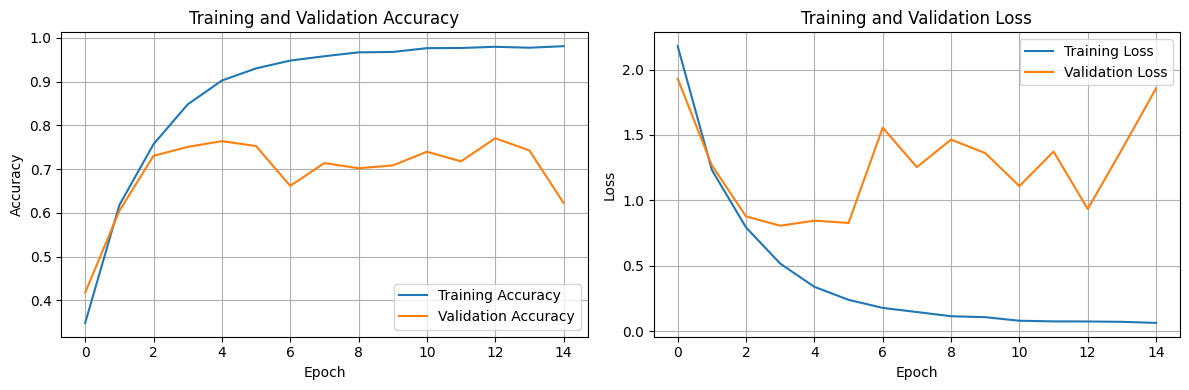

In [ ]:
plot_history(history)

In [ ]:
_ = plot_model(model_temp)

In [ ]:
eval(model_temp, x_test_cnn)

244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6227 - loss: 1.8562

Acurácia da CNN no conjunto de teste: 0.6227


In [ ]:
model = get_best_model(x_test_cnn)

244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7706 - loss: 0.9338

Acurácia da CNN no conjunto de teste: 0.7706


244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


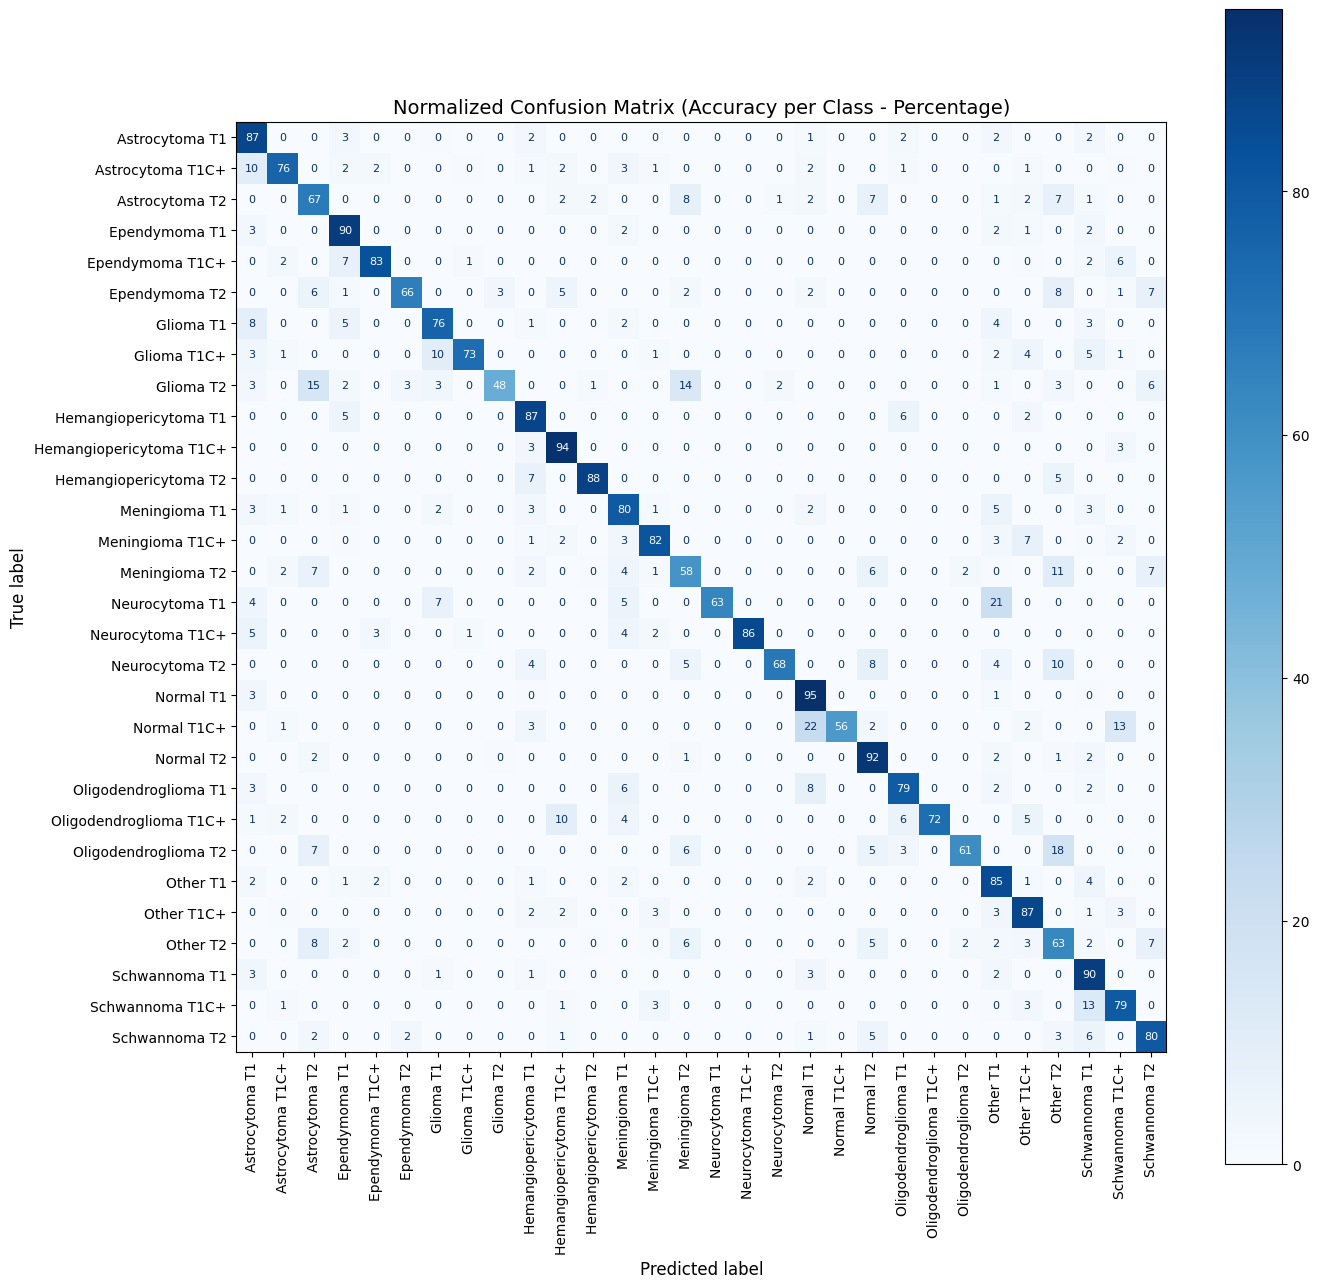

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Fazer predições no conjunto de teste
y_pred_probs = model.predict(x_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)

# Calcular a matriz de confusão
cm = confusion_matrix(y_test, y_pred)

# Normalizar a matriz de confusão para "acurácia por classe" (recall)
# Dividir cada linha pela soma da linha para obter as proporções
# Adicionar uma pequena constante para evitar divisão por zero se uma linha inteira for zero
row_sums = cm.sum(axis=1)
cm_normalized = cm.astype('float') / (row_sums[:, np.newaxis] + 1e-8)

# Multiplicar por 100 para exibir como porcentagem e usar o formato de string '.0f'
cm_normalized = cm_normalized * 100

# Exibir a matriz de confusão normalizada
fig, ax = plt.subplots(figsize=(15, 15)) # Increased figsize for better readability
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized, # Use the percentage matrix
    display_labels=list(class_names.values())
)
disp.plot(
    cmap=plt.cm.Blues,
    ax=ax,
    xticks_rotation='vertical',
    values_format='.0f', # Use string format for integer percentages
    text_kw={"fontsize": 8} # Set font size to 8 for better legibility
)
plt.title('Normalized Confusion Matrix (Accuracy per Class - Percentage)', fontsize=14) # Increased title font size
plt.xlabel('Predicted label', fontsize=12)
plt.ylabel('True label', fontsize=12)
plt.show()


Classe com maior acurácia: Normal T1 (95.00%)
Classe com menor acurácia: Glioma T2 (48.08%)
média das acurácias por classe: 77.06%
desvio padrão das acurácias por classe: 12.13%


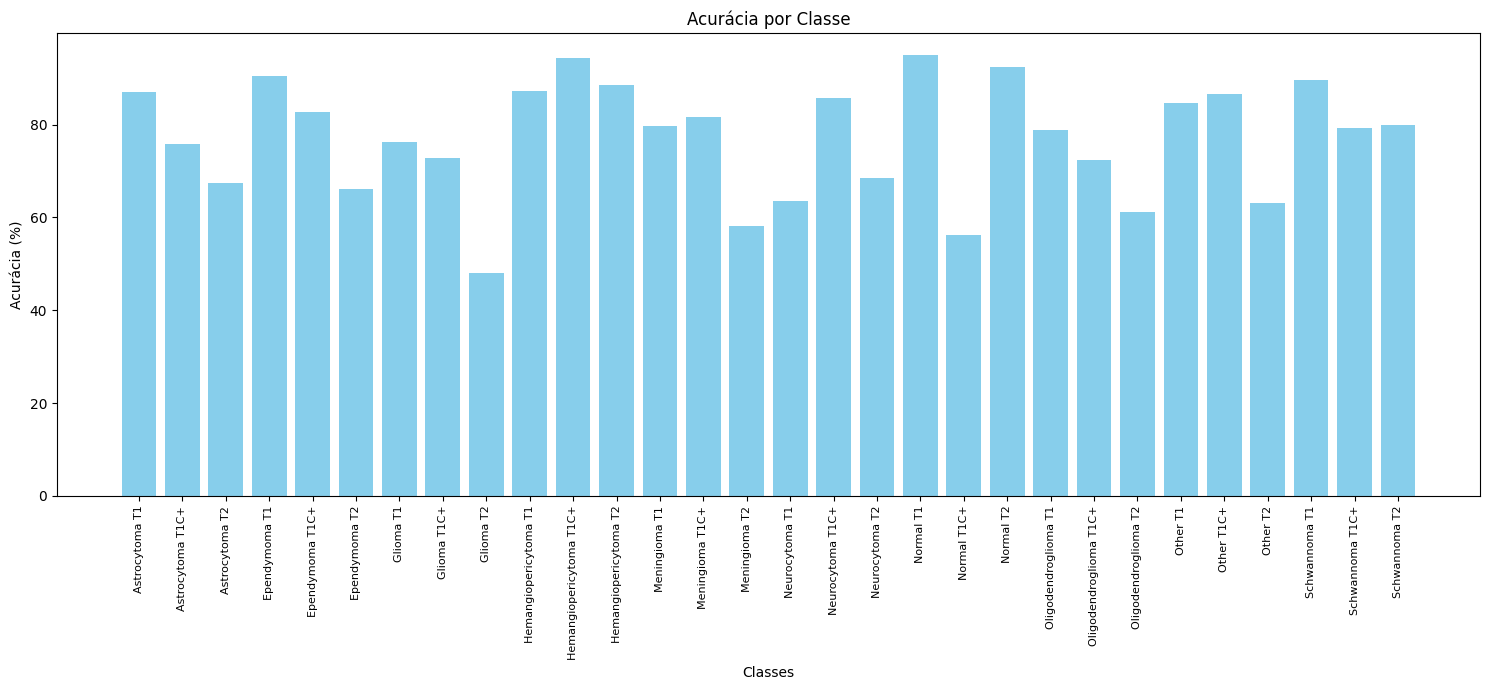

In [69]:
class_acc = np.diag(cm_normalized)

max_acc_idx = np.argmax(class_acc)
min_acc_idx = np.argmin(class_acc)

max_acc_class_name = class_names[max_acc_idx]
max_acc = class_acc[max_acc_idx]
min_acc_class_name = class_names[min_acc_idx]
min_acc = class_acc[min_acc_idx]

print(f"Classe com maior acurácia: {max_acc_class_name} ({max_acc:.2f}%)")
print(f"Classe com menor acurácia: {min_acc_class_name} ({min_acc:.2f}%)")
print(f"média das acurácias por classe: {class_acc.mean():.2f}%")
print(f"desvio padrão das acurácias por classe: {class_acc.std():.2f}%")

# Create a bar chart for class accuracies
plt.figure(figsize=(15, 7))
plt.bar(list(class_names.values()), class_acc, color='skyblue')
plt.xlabel('Classes')
plt.ylabel('Acurácia (%)')
plt.title('Acurácia por Classe')
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

A classe 'Glioma T2' (com 48.08% de acurácia) está se confundindo mais com 'Astrocytoma T2', com 15.00% dos casos.


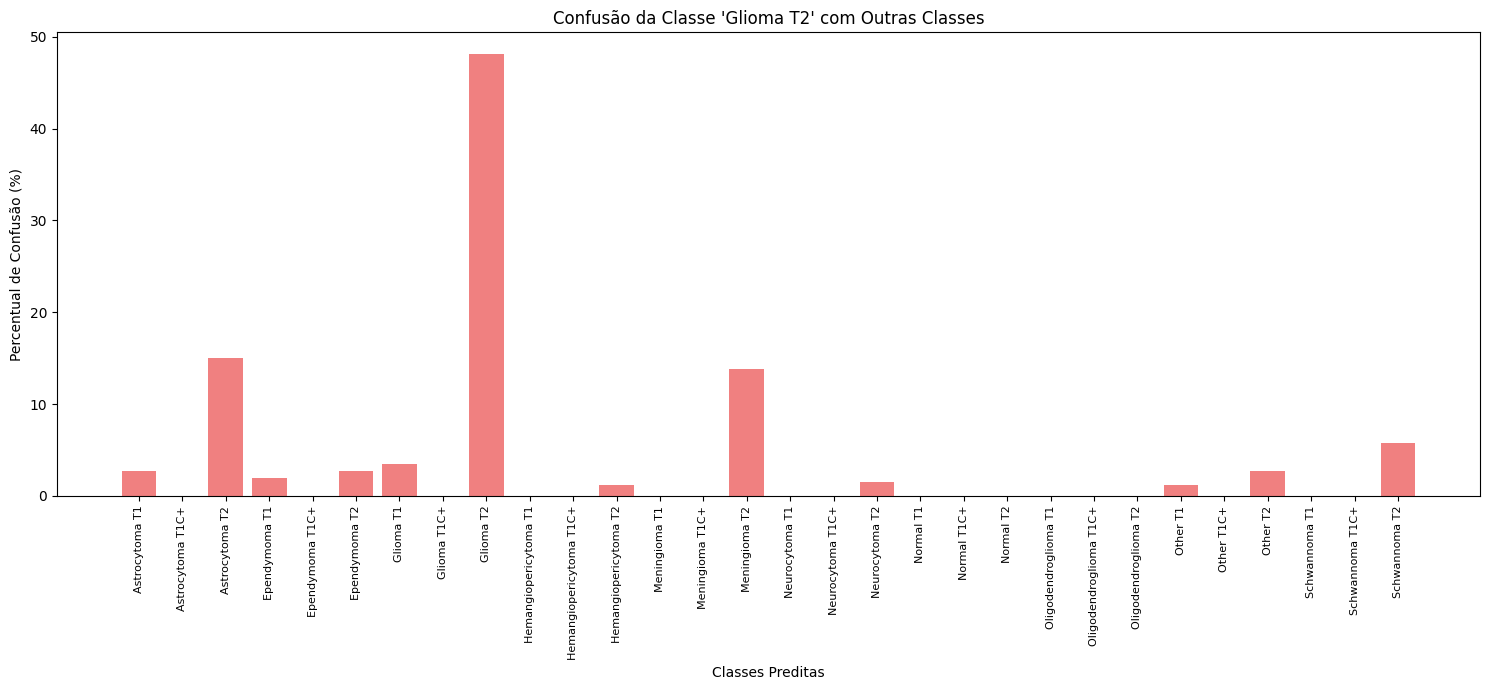

In [70]:
confused_row = cm_normalized[min_acc_idx]

confused_row_new = cm_normalized[min_acc_idx].copy()

confused_row_new[min_acc_idx] = 0

most_confused_idx = np.argmax(confused_row_new)

most_confused_class_name = class_names[most_confused_idx]
confusion_percentage = confused_row[most_confused_idx]

print(f"A classe '{min_acc_class_name}' (com {min_acc:.2f}% de acurácia) está se confundindo mais com '{most_confused_class_name}', com {confusion_percentage:.2f}% dos casos.")


plt.figure(figsize=(15, 7))
plt.bar(list(class_names.values()), confused_row, color='lightcoral')
plt.xlabel('Classes Preditas')
plt.ylabel('Percentual de Confusão (%)')
plt.title(f"Confusão da Classe '{min_acc_class_name}' com Outras Classes")
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
clear_memory()

In [ ]:
import tensorflow as tf
from keras import layers, models, Input

def residual_block(x, filters, kernel_size=(3, 3), stride=1, activate_before_res=False):
    """
    Um bloco residual que pode ser usado para construir uma ResNet.
    """
    # A função de identidade passa a entrada sem modificações
    shortcut = x

    # Camada de normalização e ativação antes do bloco convolucional, se especificado
    if activate_before_res:
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)

    # Primeira convolução
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Segunda convolução
    x = layers.Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)

    # Se as dimensões da entrada e saída do atalho não corresponderem (por causa do stride),
    # fazemos uma convolução 1x1 no atalho para corresponder às dimensões.
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding='same', kernel_initializer='he_normal')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Adiciona o atalho à saída do bloco e aplica a ativação final
    x = layers.add([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_resnet_model(input_shape, num_classes):
    """
    Constrói um modelo ResNet simplificado.
    """
    inputs = Input(shape=input_shape)
    x = inputs

    # Camada de entrada
    x = layers.Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Blocos Residuais
    x = residual_block(x, 64) # Bloco sem downsampling
    x = residual_block(x, 64) # Outro bloco sem downsampling
    x = residual_block(x, 128, stride=2) # Bloco com downsampling
    x = residual_block(x, 128)

    # x = residual_block(x, 32)
    # x = residual_block(x, 32)
    # x = residual_block(x, 32)
    # x = residual_block(x, 32)

    # Camada final de pooling e classificação
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(num_classes, activation='softmax', kernel_initializer='he_normal')(x)

    model_resnet = models.Model(inputs=inputs, outputs=x)
    return model_resnet

# Instanciar e compilar o modelo ResNet
input_shape_resnet = (*x_dims, 1) # Usando o x_dims do notebook
model = build_resnet_model(input_shape_resnet, y_dims)

model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

model.summary()


# Treinar
print("\nIniciando treinamento da CNN (API Funcional)...")
history_cnn = model.fit(
    x_train_cnn, y_train_cnn,
    epochs=15,
    batch_size=32,
    validation_data=(x_test_cnn, y_test_cnn)
)

# Avaliação final
loss, acc = model.evaluate(x_test_cnn, y_test_cnn)
print(f"\nAcurácia da CNN no conjunto de teste: {acc:.4f}")

In [ ]:
import tensorflow as tf
from keras import layers, models, Input
import numpy as np

def get_heatmap_model(model):
    """
    Retorna um modelo que gera os mapas de calor (scores pré-softmax) para TODAS as classes,
    além das probabilidades originais do modelo.

    Saídas:
      - class_heatmaps: tensor (batch, H, W, num_classes) com os logits espaciais de cada classe.
      - probs: tensor (batch, num_classes) com as probabilidades preditas pelo classificador.

    Esses mapas utilizam a projeção fiel dos pesos das camadas densas (incluindo bias e ativações
    corretas) sobre as features normalizadas da camada imediatamente anterior ao pooling global.
    """
    # 1. Encontra a camada de GlobalAveragePooling2D (ou GlobalMaxPooling2D)
    gap_layer = None
    gap_idx = None
    for idx, layer in enumerate(model.layers):
        if isinstance(layer, (layers.GlobalAveragePooling2D, layers.GlobalMaxPooling2D)):
            gap_layer = layer
            gap_idx = idx
            break
    if gap_idx is None:
        raise ValueError("Nenhuma camada GlobalAveragePooling2D/GlobalMaxPooling2D encontrada.")
    if gap_idx == 0:
        raise ValueError("A camada de pooling é a primeira camada do modelo.")

    # Camada imediatamente anterior ao pooling (ex.: BatchNormalization)
    pre_pool_layer = model.layers[gap_idx - 1]

    # 2. Camadas densas (classificação)
    dense_layers = [layer for layer in model.layers if isinstance(layer, layers.Dense)]
    if not dense_layers:
        raise ValueError("Nenhuma camada Dense encontrada.")

    # 3. Submodelo que extrai as features da camada pré-pooling
    base_model = models.Model(inputs=model.input, outputs=pre_pool_layer.output)

    # 4. Projeção espacial equivalente às camadas densas
    x = base_model.output  # (batch, H, W, C)

    for i, dense in enumerate(dense_layers):
        kernel, bias = dense.get_weights()
        out_dim = kernel.shape[1]
        # Kernel da Dense: (in_dim, out_dim) -> Conv2D 1x1: (1, 1, in_dim, out_dim)
        kernel_4d = np.reshape(kernel, (1, 1, kernel.shape[0], out_dim))

        # Mantém a ativação original, exceto na última camada (usamos linear para obter logits)
        activation = dense.activation
        if i == len(dense_layers) - 1:
            activation = tf.keras.activations.linear   # sem softmax

        conv = layers.Conv2D(
            out_dim, (1, 1),
            use_bias=True,
            kernel_initializer=tf.constant_initializer(kernel_4d),
            bias_initializer=tf.constant_initializer(bias),
            activation=activation,
            trainable=False,
            name=f'spatial_dense_{i}'
        )
        x = conv(x)

    # x: (batch, H, W, num_classes) – scores espaciais (logits) para TODAS as classes

    # 5. Probabilidades originais do classificador
    probs = model.output  # (batch, num_classes)

    # 6. Modelo final com duas saídas
    heatmap_model = models.Model(inputs=model.input, outputs=[x, probs], name='heatmap_all_classes')
    return heatmap_model

# Exemplo de uso:
# model_heatmap = get_heatmap_model(model_cnn)
# heatmaps, probs = model_heatmap.predict(x_test_cnn)
# heatmaps.shape -> (num_amostras, H, W, num_classes)
# heatmaps[0, :, :, k] é o mapa de calor da classe k para a primeira amostra
# Para visualizar a classe predita: pred = np.argmax(probs[0]); plt.imshow(heatmaps[0, :, :, pred])

model_heatmap = get_heatmap_model(model)
model_heatmap.summary()

In [ ]:
[i.shape for i in model_heatmap(x_test_cnn[0][None,...])]

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def display_all_class_heatmaps(idx, x_norm_data, x_raw_data, y_labels, heatmap_model, class_names_map, n_display_probs=5):
    # 1. Prepare image
    img_norm = x_norm_data[idx]
    if len(img_norm.shape) == 2:
        img_norm = img_norm[..., np.newaxis]
    img_tensor = np.expand_dims(img_norm, axis=0)

    # 2. Get all class heatmaps and probabilities
    all_heatmaps, probs = heatmap_model(img_tensor)
    all_heatmaps = all_heatmaps[0].numpy() # Shape: (H_feat, W_feat, num_classes)
    probs_flat = probs[0].numpy() # Shape: (num_classes,)
    num_classes = all_heatmaps.shape[-1]

    # Global normalization for this specific prediction (across all classes)
    global_min = all_heatmaps.min()
    global_max = all_heatmaps.max()

    pred_class = np.argmax(probs_flat)
    true_class = y_labels[idx]

    # Determine color for the predicted class text
    prediction_color = 'blue' if pred_class == true_class else 'red'

    # 3. Select indices to display
    # Get sorted indices by probability
    sorted_prob_indices = np.argsort(probs_flat)[::-1] # Descending order

    # Initialize set of indices to plot
    indices_to_plot_set = set()
    indices_to_plot_set.add(true_class) # Always show true class
    indices_to_plot_set.add(pred_class) # Always show predicted class

    # Add top N probabilities
    for i in range(min(n_display_probs, num_classes)):
        indices_to_plot_set.add(sorted_prob_indices[i])

    # Add bottom N probabilities (if distinct from top N and true/pred)
    # Ensure we don't pick the same indices if num_classes is small
    bottom_n_indices = np.argsort(probs_flat) # Ascending order
    count_added = 0
    for i in range(num_classes):
        if bottom_n_indices[i] not in indices_to_plot_set:
            indices_to_plot_set.add(bottom_n_indices[i])
            count_added += 1
        if count_added >= n_display_probs: # Stop after adding N unique bottom values
            break

    # Sort indices to plot by their probability in descending order
    indices_to_plot = sorted(list(indices_to_plot_set), key=lambda k: probs_flat[k], reverse=True)
    num_plots = len(indices_to_plot) + 1 # +1 for the original image

    # 4. Original raw image info
    img_raw = x_raw_data[idx]
    h, w = img_raw.shape

    # 5. Plotting
    # Adjust figure size based on the number of heatmaps to display
    fig_width = 4 * num_plots
    plt.figure(figsize=(fig_width, 4))

    # Show Original
    plt.subplot(1, num_plots, 1)
    plt.imshow(img_raw, cmap='gray')
    plt.title(f"Original\nTrue: {class_names_map[true_class]} ({true_class})", color='black')
    plt.axis('off')

    # Show Heatmap for each selected class
    for i, k in enumerate(indices_to_plot):
        heatmap = all_heatmaps[:, :, k]
        # Resize to original image size
        heatmap_resized = cv2.resize(heatmap, (w, h))
        # Normalize based on the entire prediction array (all classes)
        heatmap_norm = (heatmap_resized - global_min) / (global_max - global_min + 1e-8)

        plt.subplot(1, num_plots, i + 2) # +2 because 1 is original, +1 for 0-indexing
        plt.imshow(img_raw, cmap='gray')
        plt.imshow(heatmap_norm, cmap='jet', alpha=0.4, vmin=0, vmax=1)

        # If this is the predicted class, use red if wrong, blue if correct
        # Other classes remain black
        title_color = prediction_color if k == pred_class else 'black'
        plt.title(f"Class: {class_names_map[k]}\nProb: {probs_flat[k]:.2f}", color=title_color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Visualize samples with consistent color mapping and error highlighting
random_indices = np.random.choice(len(x_all_norm), 10, replace=False) # Showing fewer examples for conciseness
for idx in random_indices:
    display_all_class_heatmaps(idx, x_all_norm, x_raw, y_all, model_heatmap, class_names, n_display_probs=2)


In [ ]:
import tensorflow as tf
from keras import layers, models


model = models.Sequential([
    layers.Flatten(input_shape=x_dims),          # Transforma a imagem 28x28 em um vetor de 784 pixels
    layers.Dense(128, activation='relu'),          # Camada oculta com 128 neurônios
    layers.Dropout(0.2),                           # Camada de regularização para evitar overfitting
    layers.Dense(y_dims, activation='softmax')         # Camada de saída com 10 neurônios (0 a 9)
])

# 3. Compilar o modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. Treinar o modelo
model.fit(x_train_norm, y_train_norm, epochs=5)

model.evaluate(x_test_norm, y_test_norm)

In [ ]:
model.fit(x_train_norm, y_train_norm, epochs=5)

model.evaluate(x_test_norm, y_test_norm)

In [ ]:
base_model.output

In [ ]:
model_vgg.summary()

In [ ]:
x_train_balanced.max(), x_train_balanced.min()

In [ ]:
from keras.applications import VGG16
from keras.applications.vgg16 import preprocess_input
from keras import layers, models
import numpy as np


x_train_transfer_final = preprocess_input(x_train_transfer.astype('float32'))
x_test_transfer_final = preprocess_input(x_test_transfer.astype('float32'))

x_transfer_dim = x_train_transfer.shape[1:]

# 2. Transfer Learning: Carregar VGG16 pré-treinada sem o topo
base_model = VGG16(weights='imagenet', include_top=False, input_shape=x_transfer_dim, pooling='avg')
base_model.trainable = False  # Congelar pesos da base

# 3. Adicionar novas camadas de classificação
model = models.Sequential([
    base_model,
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(y_dims, activation='softmax')
])


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
checkpoint_filepath = 'best_model_cnn.keras'
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    # verbose=1
)

# Treinar
print("\nIniciando treinamento da CNN (API Funcional)...")
history_cnn = model.fit(
    x_train_transfer_final, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(x_test_transfer_final, y_test),
    callbacks=[model_checkpoint_callback] # Adicionar o callback aqui
)

In [ ]:
import tensorflow as tf
from keras import layers, models
from keras.applications.convnext import preprocess_input, ConvNeXtBase
import keras

x_train_transfer_raw = np.repeat(x_train_balanced[..., np.newaxis], 3, -1)
x_test_transfer_raw = np.repeat(x_test_balanced[..., np.newaxis], 3, -1)

x_train_transfer = preprocess_input(x_train_transfer_raw.astype('float32'))
x_test_transfer = preprocess_input(x_test_transfer_raw.astype('float32'))
y_train_transfer = y_train_balanced
y_test_transfer = y_test_balanced

x_transfer_dim = x_train_transfer.shape[1:]
# Carrega o ConvNeXtBase sem o topo, com pesos ImageNet
base_model = ConvNeXtBase(
    include_top=False,
    weights='imagenet',
    input_shape=x_transfer_dim,
    pooling='avg'  # adiciona global average pooling no lugar do topo
)

# Congela a base
base_model.trainable = False

# Adiciona suas camadas de classificação
model = models.Sequential([
    base_model,
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(y_dims, activation='softmax')
])


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("--- Treinando Transfer Learning com preprocess_input correto ---")
model.fit(x_train_transfer, y_train_transfer, epochs=15, batch_size=32, validation_data=(x_test_transfer, y_test_transfer))

# Avaliação final
loss, acc = model.evaluate(x_test_transfer, y_test_transfer)
print(f"\nAcurácia final com transfer16: {acc:.4f}")

In [ ]:
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # LR bem menor
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


print("--- Treinando Transfer Learning com preprocess_input correto ---")
history_cnn = model.fit(
    x_train_transfer_final, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(x_test_transfer_final, y_test),
    callbacks=[model_checkpoint_callback] # Adicionar o callback aqui
)

In [ ]:
x_train_transfer.shape[1:]

In [ ]:
print("--- Treinando Transfer Learning com preprocess_input correto ---")
model_vgg.fit(x_train_vgg, y_train_vgg, epochs=15, batch_size=32, validation_data=(x_test_vgg, y_test_vgg))

# Avaliação final
loss, acc = model_vgg.evaluate(x_test_vgg, y_test_vgg)
print(f"\nAcurácia final com VGG16: {acc:.4f}")

In [ ]:
current_x_test = x_test_cnn

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 5. Fazer predições no conjunto de teste
predictions = model.predict(current_x_test)

# Selecionar 10 índices aleatórios
random_indices = np.random.choice(len(current_x_test), 10, replace=False)

# Visualizando as predições aleatórias
plt.figure(figsize=(12, 6))
for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(current_x_test[idx], cmap='gray')

    predicted_label = np.argmax(predictions[idx])
    true_label = y_test[idx]

    # Cor do título: azul se correto, vermelho se incorreto
    color = 'blue' if predicted_label == true_label else 'red'

    plt.title(f"Real: {true_label}\nPred: {predicted_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()